# **Deeper Player Scouting**

This notebook investigates the reasons behind player performance rather than relying on total points alone. It examines form, expected involvement, efficiency, minutes, ownership, and upcoming fixtures to create a more informed scouting shortlist.

## **1. Data Setup**

This notebook continues the work from `Fantasy_Scout.ipynb`. It independently retrieves the same player, team, and fixture data so the deeper scouting analysis can be run as a separate workflow without depending on the previous notebook's active kernel.


In [5]:
import pandas as pd
import requests

BASE_URL = "https://fantasy.premierleague.com/api"
MIN_MINUTES = 90


def fetch_json(url: str, timeout: int = 20):
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return response.json()


bootstrap = fetch_json(f"{BASE_URL}/bootstrap-static/")
fixtures_payload = fetch_json(f"{BASE_URL}/fixtures/")

team_map = {
    team["id"]: team["name"]
    for team in bootstrap.get("teams", [])
}
position_map = {
    position["id"]: position.get("singular_name_short", position.get("singular_name"))
    for position in bootstrap.get("element_types", [])
}

players_df = pd.DataFrame(bootstrap.get("elements", []))
players_df = players_df.rename(columns={
    "id": "player_id",
    "web_name": "name",
    "element_type": "position_id",
    "now_cost": "price_tenths",
    "selected_by_percent": "ownership_pct",
})

players_df["team"] = players_df["team"].map(team_map)
players_df["position"] = players_df["position_id"].map(position_map)
players_df["price"] = pd.to_numeric(players_df["price_tenths"], errors="coerce") / 10

numeric_columns = [
    "total_points",
    "form",
    "expected_goals",
    "expected_assists",
    "ict_index",
    "minutes",
    "goals_scored",
    "assists",
    "clean_sheets",
    "saves",
    "goals_conceded",
    "bonus",
    "ownership_pct",
]
for column in numeric_columns:
    players_df[column] = pd.to_numeric(players_df[column], errors="coerce").fillna(0)

players_df = players_df.rename(columns={
    "expected_goals": "xg",
    "expected_assists": "xa",
})

current_event = int(bootstrap.get("current_event", 1))
upcoming_fixtures = [
    fixture for fixture in fixtures_payload
    if fixture.get("event") is not None
    and fixture.get("finished") is False
    and current_event <= int(fixture["event"]) <= current_event + 4
]

fixture_rows = []
for fixture in upcoming_fixtures:
    fixture_rows.extend([
        {
            "event": fixture["event"],
            "team_id": fixture["team_h"],
            "team_name": team_map.get(fixture["team_h"]),
            "opponent": team_map.get(fixture["team_a"]),
            "is_home": True,
            "difficulty": fixture.get("team_h_difficulty"),
        },
        {
            "event": fixture["event"],
            "team_id": fixture["team_a"],
            "team_name": team_map.get(fixture["team_a"]),
            "opponent": team_map.get(fixture["team_h"]),
            "is_home": False,
            "difficulty": fixture.get("team_a_difficulty"),
        },
    ])

fixtures_df = pd.DataFrame(fixture_rows)
print(f"Loaded {len(players_df)} players and {len(fixtures_df)} team-fixture rows.")
print(f"Early-season minimum minutes filter: {MIN_MINUTES}")


Loaded 652 players and 60 team-fixture rows.
Early-season minimum minutes filter: 90


## **2. Recent Form and Reliability**

This section identifies players combining points, form, and dependable playing time.

In [6]:
# **2.1 Form and minutes**

form_view = players_df[
    (players_df["minutes"] >= MIN_MINUTES)
    & (players_df["status"] == "a")
].copy()

form_view["points_per_90"] = form_view["total_points"] / (form_view["minutes"] / 90).replace(0, pd.NA)

form_view = form_view.sort_values(
    ["form", "points_per_90", "minutes"],
    ascending=False,
)

print(form_view[[
    "name", "position", "team", "price", "form", "minutes",
    "total_points", "points_per_90", "ownership_pct",
]].head(20))


             name position       team  price  form  minutes  total_points  \
507   B.Fernandes      MID    Man Utd   12.0  12.5      180            25   
473        Cherki      MID   Man City    7.7  11.0      108            22   
318         Ajayi      DEF  Hull City    4.1  10.0      153            20   
11           Saka      MID    Arsenal    9.5  10.0      157            20   
7       Calafiori      DEF    Arsenal    5.6  10.0      170            20   
171        Palmer      MID    Chelsea    9.6  10.0      172            20   
179    João Pedro      FWD    Chelsea    7.7  10.0      180            20   
342      Tzolakis      GKP  Hull City    4.6  10.0      180            20   
117     M.Sangaré      MID  Brentford    5.7   9.0      165            18   
9           White      DEF    Arsenal    5.5   9.0      180            18   
264     Tarkowski      DEF    Everton    6.0   9.0      180            18   
535        Elanga      MID  Newcastle    6.1   8.5      156            17   

## **3. Expected Performance and Efficiency**

Expected goals and expected assists help show whether a player's underlying attacking involvement supports their actual returns.

In [7]:
# **3.1 Actual returns compared with expected involvement**

expected_view = players_df[
    (players_df["minutes"] >= MIN_MINUTES)
    & (players_df["position"].isin(["MID", "FWD"]))
].copy()

expected_view["goal_difference"] = expected_view["goals_scored"] - expected_view["xg"]
expected_view["assist_difference"] = expected_view["assists"] - expected_view["xa"]
expected_view["attacking_involvement"] = expected_view["xg"] + expected_view["xa"]

print(expected_view.sort_values("attacking_involvement", ascending=False)[[
    "name", "position", "team", "price", "goals_scored", "xg",
    "assists", "xa", "goal_difference", "assist_difference",
]].head(20))


              name position            team  price  goals_scored    xg  \
507    B.Fernandes      MID         Man Utd   12.0             3  2.10   
508         Mbeumo      MID         Man Utd    8.0             1  2.26   
156         Rogers      MID         Chelsea    7.5             1  1.10   
450           Isak      FWD       Liverpool    9.0             1  2.08   
281          Barry      FWD         Everton    5.5             1  1.93   
179     João Pedro      FWD         Chelsea    7.7             2  1.86   
114         Thiago      FWD       Brentford    8.0             0  1.80   
472          Foden      MID        Man City    7.0             0  0.99   
248        Nketiah      FWD  Crystal Palace    5.5             0  0.96   
439     Szoboszlai      MID       Liverpool    7.0             1  1.01   
482        Haaland      FWD        Man City   15.5             2  1.40   
473         Cherki      MID        Man City    7.7             2  0.35   
11            Saka      MID         Ar

In [8]:
# **3.2 Points and attacking output per 90 minutes**

per90_view = players_df[players_df["minutes"] >= MIN_MINUTES].copy()
minutes_factor = per90_view["minutes"] / 90
per90_view["points_per_90"] = per90_view["total_points"] / minutes_factor.replace(0, pd.NA)
per90_view["xg_per_90"] = per90_view["xg"] / minutes_factor.replace(0, pd.NA)
per90_view["xa_per_90"] = per90_view["xa"] / minutes_factor.replace(0, pd.NA)
per90_view["points_per_price"] = per90_view["total_points"] / per90_view["price"].replace(0, pd.NA)

print(per90_view.sort_values("points_per_90", ascending=False)[[
    "name", "position", "team", "price", "minutes", "points_per_90",
    "xg_per_90", "xa_per_90", "points_per_price",
]].head(20))


            name position           team  price  minutes  points_per_90  \
473       Cherki      MID       Man City    7.7      108      18.333333   
507  B.Fernandes      MID        Man Utd   12.0      180      12.500000   
346        Mendy      DEF      Hull City    4.0      121      11.900826   
318        Ajayi      DEF      Hull City    4.1      153      11.764706   
11          Saka      MID        Arsenal    9.5      157      11.464968   
7      Calafiori      DEF        Arsenal    5.6      170      10.588235   
171       Palmer      MID        Chelsea    9.6      172      10.465116   
179   João Pedro      FWD        Chelsea    7.7      180      10.000000   
342     Tzolakis      GKP      Hull City    4.6      180      10.000000   
117    M.Sangaré      MID      Brentford    5.7      165       9.818182   
535       Elanga      MID      Newcastle    6.1      156       9.807692   
438        Gakpo      MID      Liverpool    7.0      160       9.562500   
123    De Cuyper      DEF

## **4. Fixture Suitability**

This section connects player teams with the next five gameweeks to identify favourable schedules.

In [9]:
# **4.1 Team fixture difficulty**

fixture_summary = (
    fixtures_df.groupby("team_name", as_index=False)
    .agg(
        fixtures=("event", "count"),
        average_difficulty=("difficulty", "mean"),
        home_fixtures=("is_home", "sum"),
    )
    .sort_values(["average_difficulty", "fixtures"])
)

print(fixture_summary.head(20))

         team_name  fixtures  average_difficulty  home_fixtures
13       Liverpool         3            2.333333              1
1      Aston Villa         3            2.666667              1
4         Brighton         3            2.666667              2
7   Crystal Palace         3            2.666667              1
12           Leeds         3            2.666667              2
14        Man City         3            2.666667              2
16       Newcastle         3            2.666667              2
3        Brentford         3            3.000000              2
8          Everton         3            3.000000              2
17   Nott'm Forest         3            3.000000              2
18           Spurs         3            3.000000              2
0          Arsenal         3            3.333333              1
2      Bournemouth         3            3.333333              2
5          Chelsea         3            3.333333              1
6    Coventry City         3            

## **5. Scouting Shortlist**

The shortlist combines playing time, form, output, value, and ownership. It is a starting point for human judgement rather than an automatic transfer recommendation.

In [10]:
# **5.1 Balanced shortlist**

scouting_view = players_df[
    (players_df["minutes"] >= MIN_MINUTES)
    & (players_df["status"] == "a")
].copy()

scouting_view["points_per_price"] = scouting_view["total_points"] / scouting_view["price"].replace(0, pd.NA)
scouting_view["points_per_90"] = scouting_view["total_points"] / (scouting_view["minutes"] / 90).replace(0, pd.NA)
scouting_view["attacking_involvement"] = scouting_view["xg"] + scouting_view["xa"]

scouting_view["scouting_score"] = (
    scouting_view["points_per_90"].rank(pct=True)
    + scouting_view["points_per_price"].rank(pct=True)
    + scouting_view["form"].rank(pct=True)
    + scouting_view["attacking_involvement"].rank(pct=True)
)

shortlist = scouting_view.sort_values("scouting_score", ascending=False)
print(shortlist[[
    "name", "position", "team", "price", "form", "minutes",
    "total_points", "points_per_90", "points_per_price",
    "attacking_involvement", "ownership_pct", "scouting_score",
]].head(20))


             name position           team  price  form  minutes  total_points  \
473        Cherki      MID       Man City    7.7  11.0      108            22   
123     De Cuyper      DEF       Brighton    4.7   8.5      167            17   
507   B.Fernandes      MID        Man Utd   12.0  12.5      180            25   
179    João Pedro      FWD        Chelsea    7.7  10.0      180            20   
7       Calafiori      DEF        Arsenal    5.6  10.0      170            20   
11           Saka      MID        Arsenal    9.5  10.0      157            20   
171        Palmer      MID        Chelsea    9.6  10.0      172            20   
318         Ajayi      DEF      Hull City    4.1  10.0      153            20   
438         Gakpo      MID      Liverpool    7.0   8.5      160            17   
97   Lewis-Potter      MID      Brentford    5.5   8.0      177            16   
117     M.Sangaré      MID      Brentford    5.7   9.0      165            18   
99         Kayode      DEF  

## **6. Position-Based Player Assessments**

Each position is assessed using the statistics most relevant to its FPL scoring role. These are screening views for comparison, not automatic transfer recommendations.


In [11]:
### **6.1 Goalkeeper assessment**

In [19]:
keepers = players_df[
    (players_df["position"] == "GKP")
    & (players_df["minutes"] >= MIN_MINUTES)
].copy()

keepers["points_per_90"] = keepers["total_points"] / (keepers["minutes"] / 90)
keepers["saves_per_90"] = keepers["saves"] / (keepers["minutes"] / 90)
keepers["attacking_contribution"] = keepers["goals_scored"] + keepers["assists"]

keepers = keepers.sort_values(
    ["attacking_contribution", "clean_sheets", "saves_per_90", "points_per_90"],
    ascending=False,
)

print(keepers[[
    "name", "team", "price", "minutes", "total_points",
    "clean_sheets", "saves", "saves_per_90", "goals_conceded",
    "goals_scored", "assists", "attacking_contribution",
    "points_per_90", "ownership_pct",
]].head(15))

print("\nGoalkeeper attacking contributions:")
attacking_keepers = keepers[keepers["attacking_contribution"] > 0]
if attacking_keepers.empty:
    print("No eligible goalkeepers have scored or assisted yet.")
else:
    print(attacking_keepers[[
        "name", "team", "goals_scored", "assists", "attacking_contribution",
    ]])

           name            team  price  minutes  total_points  clean_sheets  \
342    Tzolakis       Hull City    4.6      180            20             2   
0          Raya         Arsenal    6.0      180            12             2   
548    Horníček       Newcastle    5.0      180             8             1   
261    Pickford         Everton    5.5      180            10             1   
413    Trafford           Leeds    5.0      180            12             1   
93     Kelleher       Brentford    5.0      180             9             1   
623       Roefs      Sunderland    5.0      180             7             1   
119  Verbruggen        Brighton    4.5      180             6             1   
64     Petrović     Bournemouth    4.5      180             5             0   
155    Martinez         Chelsea    5.0       90             2             0   
159     Sánchez         Chelsea    4.9       90             2             0   
383    Scherpen    Ipswich Town    4.5      180     

### **6.2 Defender assessment**

In [20]:
defenders = players_df[
    (players_df["position"] == "DEF")
    & (players_df["minutes"] >= MIN_MINUTES)
].copy()

defenders["points_per_90"] = defenders["total_points"] / (defenders["minutes"] / 90)

defenders["defender_output"] = (
    defenders["clean_sheets"]
    + defenders["goals_scored"]
    + defenders["assists"]
    + defenders["bonus"]
)

defenders = defenders.sort_values(
    ["defender_output", "points_per_90", "minutes"],
    ascending=False,
)

print(defenders[[
    "name", "team", "price", "minutes", "total_points",
    "clean_sheets", "goals_scored", "assists", "bonus",
    "defender_output", "points_per_90", "ownership_pct",
]].head(20))

          name           team  price  minutes  total_points  clean_sheets  \
7    Calafiori        Arsenal    5.6      170            20             2   
9        White        Arsenal    5.5      180            18             2   
318      Ajayi      Hull City    4.1      153            20             2   
123  De Cuyper       Brighton    4.7      167            17             1   
264  Tarkowski        Everton    6.0      180            18             1   
531       Hall      Newcastle    5.1      180            14             1   
549      Dedić      Newcastle    4.5      180            12             1   
346      Mendy      Hull City    4.0      121            16             1   
316       Egan      Hull City    4.0      180            17             2   
99      Kayode      Brentford    4.6      162            15             1   
465   Gvardiol       Man City    5.6      164            14             0   
392      Bijol          Leeds    5.0      135            11             1   

### **6.3 Midfielder assessment**


In [13]:

midfielders = players_df[
    (players_df["position"] == "MID")
    & (players_df["minutes"] >= MIN_MINUTES)
].copy()

midfielders["points_per_90"] = midfielders["total_points"] / (midfielders["minutes"] / 90)
midfielders["attacking_involvement"] = midfielders["xg"] + midfielders["xa"]
midfielders["returns"] = midfielders["goals_scored"] + midfielders["assists"]

midfielders = midfielders.sort_values(
    ["attacking_involvement", "returns", "points_per_90"],
    ascending=False,
)

print(midfielders[[
    "name", "team", "price", "minutes", "total_points", "form",
    "goals_scored", "assists", "xg", "xa", "attacking_involvement",
    "points_per_90", "ownership_pct",
]].head(20))


             name           team  price  minutes  total_points  form  \
507   B.Fernandes        Man Utd   12.0      180            25  12.5   
508        Mbeumo        Man Utd    8.0      180            13   6.5   
156        Rogers        Chelsea    7.5      171            13   6.5   
472         Foden       Man City    7.0      171            10   5.0   
439    Szoboszlai      Liverpool    7.0      180            12   6.0   
473        Cherki       Man City    7.7      108            22  11.0   
11           Saka        Arsenal    9.5      157            20  10.0   
171        Palmer        Chelsea    9.6      172            20  10.0   
385        Enciso   Ipswich Town    5.5      160            10   5.0   
135         Gomez       Brighton    5.0      175            11   5.5   
438         Gakpo      Liverpool    7.0      160            17   8.5   
97   Lewis-Potter      Brentford    5.5      177            16   8.0   
567   Gibbs-White  Nott'm Forest    7.9      180            15  

### **6.4 Attacker assessment**


In [14]:

attackers = players_df[
    (players_df["position"] == "FWD")
    & (players_df["minutes"] >= MIN_MINUTES)
].copy()

attackers["points_per_90"] = attackers["total_points"] / (attackers["minutes"] / 90)
attackers["goal_threat"] = attackers["xg"] + attackers["goals_scored"]
attackers["returns"] = attackers["goals_scored"] + attackers["assists"]

attackers = attackers.sort_values(
    ["goal_threat", "returns", "points_per_90"],
    ascending=False,
)

print(attackers[[
    "name", "team", "price", "minutes", "total_points", "form",
    "goals_scored", "assists", "xg", "goal_threat", "returns",
    "points_per_90", "ownership_pct",
]].head(20))


              name            team  price  minutes  total_points  form  \
179     João Pedro         Chelsea    7.7      180            20  10.0   
482        Haaland        Man City   15.5      180            15   7.5   
450           Isak       Liverpool    9.0      180            10   5.0   
281          Barry         Everton    5.5      147            10   5.0   
544          Wissa       Newcastle    6.1      171            12   6.0   
409  Calvert-Lewin           Leeds    6.0      180             9   4.5   
303        Gonzalo          Fulham    6.0      180             8   4.0   
372       Emersonn    Ipswich Town    5.5      110            10   5.0   
114         Thiago       Brentford    8.0      172             2   1.0   
24         Havertz         Arsenal    7.5      180             8   4.0   
248        Nketiah  Crystal Palace    5.5      122             3   1.5   
577     Igor Jesus   Nott'm Forest    5.9      180             3   1.5   
218        Awoniyi   Coventry City    

## **7. Scouting Visualizations**

These visualizations provide a quick representation of the deeper scouting data and make relationships between price, output, expected involvement, and position easier to compare.


### **7.1 Points versus price**


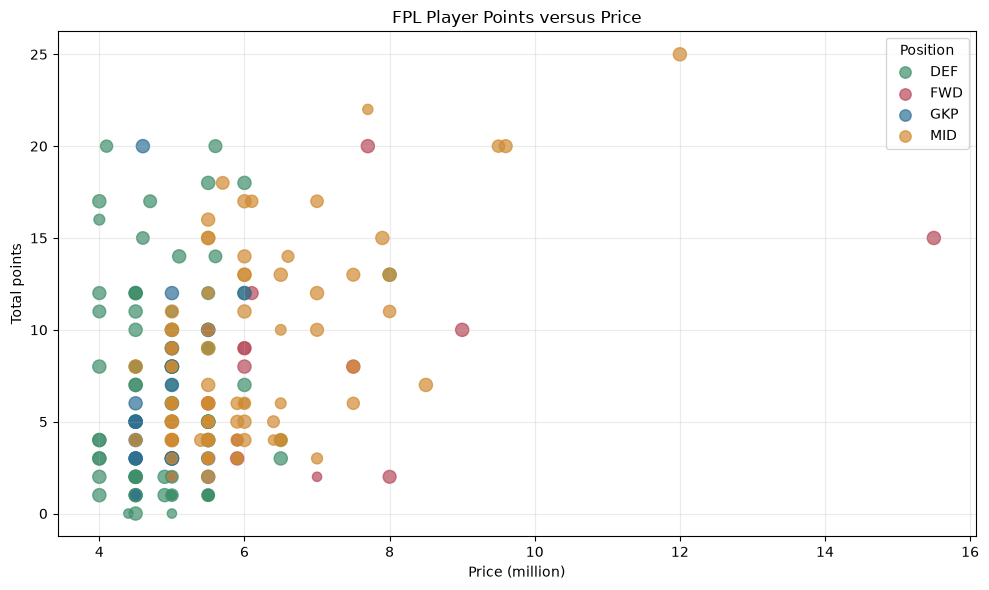

In [15]:

import matplotlib.pyplot as plt

plot_data = players_df[
    (players_df["minutes"] >= MIN_MINUTES)
    & (players_df["status"] == "a")
].copy()

position_colors = {
    "GKP": "#2f6f95",
    "DEF": "#3f8f6b",
    "MID": "#d08b32",
    "FWD": "#b84a5a",
}

fig, ax = plt.subplots(figsize=(10, 6))
for position, group in plot_data.groupby("position"):
    ax.scatter(
        group["price"],
        group["total_points"],
        s=group["minutes"].clip(lower=30) / 2,
        alpha=0.7,
        label=position,
        color=position_colors.get(position, "#666666"),
    )

ax.set_title("FPL Player Points versus Price")
ax.set_xlabel("Price (million)")
ax.set_ylabel("Total points")
ax.legend(title="Position")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### **7.2 Expected attacking involvement**


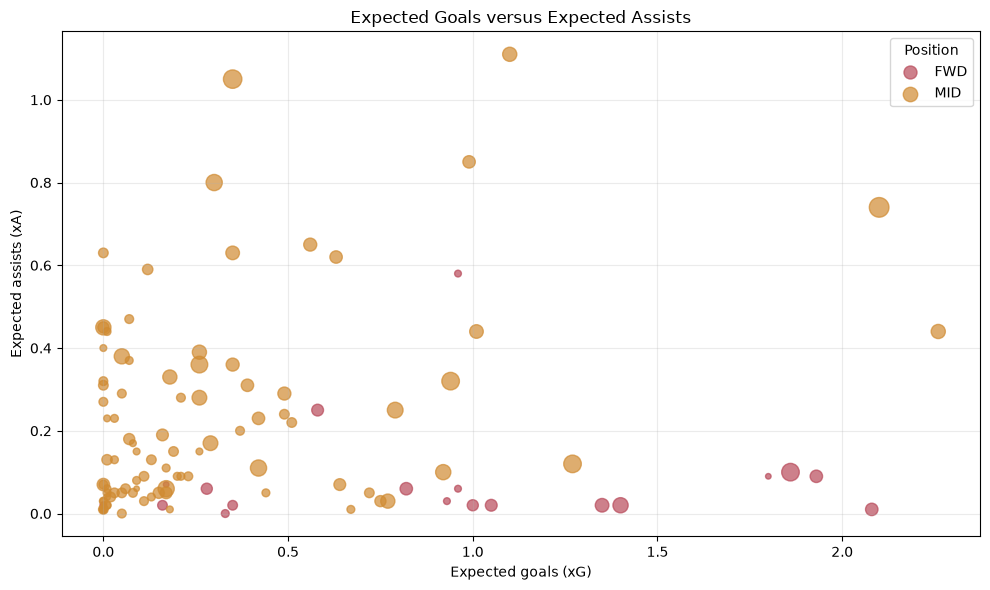

In [16]:

attacking_plot = players_df[
    (players_df["minutes"] >= MIN_MINUTES)
    & (players_df["position"].isin(["MID", "FWD"]))
    & (players_df["status"] == "a")
].copy()

fig, ax = plt.subplots(figsize=(10, 6))
for position, group in attacking_plot.groupby("position"):
    ax.scatter(
        group["xg"],
        group["xa"],
        s=group["total_points"].clip(lower=1) * 8,
        alpha=0.7,
        label=position,
        color=position_colors.get(position, "#666666"),
    )

ax.set_title("Expected Goals versus Expected Assists")
ax.set_xlabel("Expected goals (xG)")
ax.set_ylabel("Expected assists (xA)")
ax.legend(title="Position")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### **7.2 Expected attacking involvement**


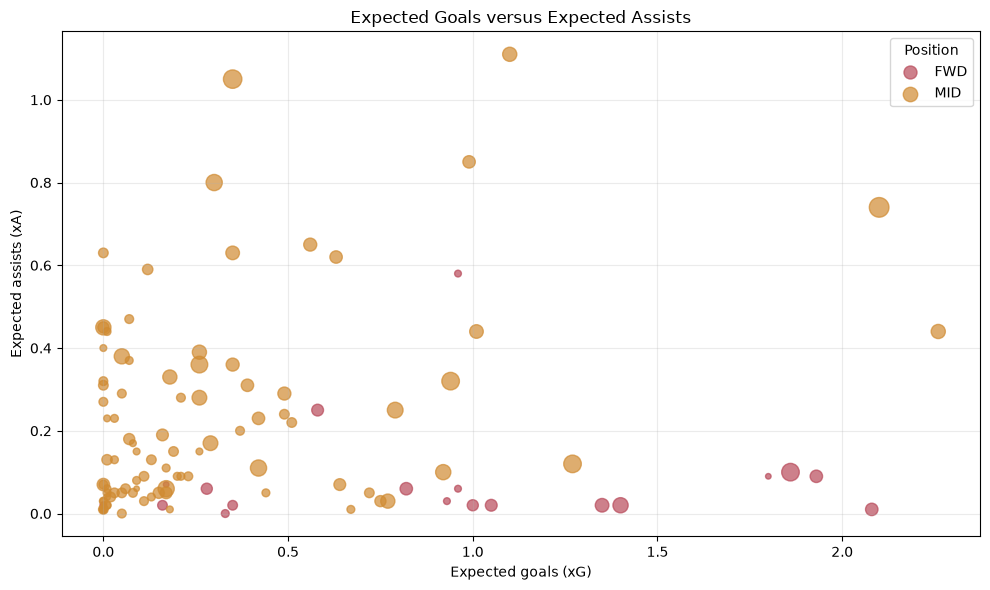

In [17]:

attacking_plot = players_df[
    (players_df["minutes"] >= MIN_MINUTES)
    & (players_df["position"].isin(["MID", "FWD"]))
    & (players_df["status"] == "a")
].copy()

fig, ax = plt.subplots(figsize=(10, 6))
for position, group in attacking_plot.groupby("position"):
    ax.scatter(
        group["xg"],
        group["xa"],
        s=group["total_points"].clip(lower=1) * 8,
        alpha=0.7,
        label=position,
        color=position_colors.get(position, "#666666"),
    )

ax.set_title("Expected Goals versus Expected Assists")
ax.set_xlabel("Expected goals (xG)")
ax.set_ylabel("Expected assists (xA)")
ax.legend(title="Position")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### **7.3 Average performance by position**


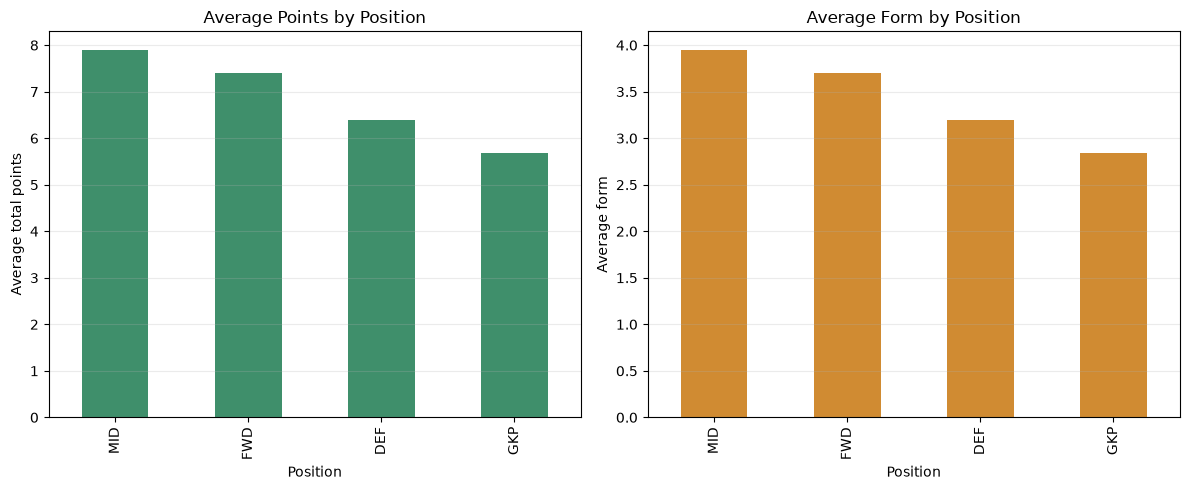

In [18]:

position_plot = (
    players_df[players_df["minutes"] >= MIN_MINUTES]
    .groupby("position", as_index=False)
    .agg(
        average_points=("total_points", "mean"),
        average_price=("price", "mean"),
        average_form=("form", "mean"),
    )
    .sort_values("average_points", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
position_plot.plot.bar(
    x="position",
    y="average_points",
    ax=axes[0],
    color="#3f8f6b",
    legend=False,
)
position_plot.plot.bar(
    x="position",
    y="average_form",
    ax=axes[1],
    color="#d08b32",
    legend=False,
)

axes[0].set_title("Average Points by Position")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Average total points")
axes[1].set_title("Average Form by Position")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Average form")
for axis in axes:
    axis.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## **8. Interpretation**

Use the outputs to distinguish reliable starters from short-term performers. A strong scouting candidate should ideally combine regular minutes, sustainable underlying numbers, acceptable price, and a favourable fixture run. Ownership and recent form add context, but neither should be used in isolation.
